# 2. Keşifsel Veri Analizi (EDA)
Bu notebook, temizlenmiş Amazon yorum verileri üzerinde görselleştirme ve istatistiksel analiz yapar.

In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from datetime import datetime

os.makedirs('results', exist_ok=True)
print('Veri yükleniyor...')
df = pd.read_csv('data/reviews_cleaned.csv')
df['text'] = df['text'].astype(str)
# Amazon yorumlarındaki HTML etiketlerini (<br /> vb.) temizle; aksi halde
# kelime bulutu ve en sık kelimelerde 'br' gibi gürültü öne çıkar.
df['text'] = df['text'].str.replace(r'<[^>]+>', ' ', regex=True)
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['review_length'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['timestamp'] = pd.to_datetime(df['Time'], unit='s')
df['year'] = df['timestamp'].dt.year

class_names = {0: 'Negatif', 1: 'Nötr', 2: 'Pozitif'}
df['class_name'] = df['label'].map(class_names)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (12, 8), 'figure.dpi': 150})

Veri yükleniyor...


## 2.1 Genel Dağılım Grafikleri

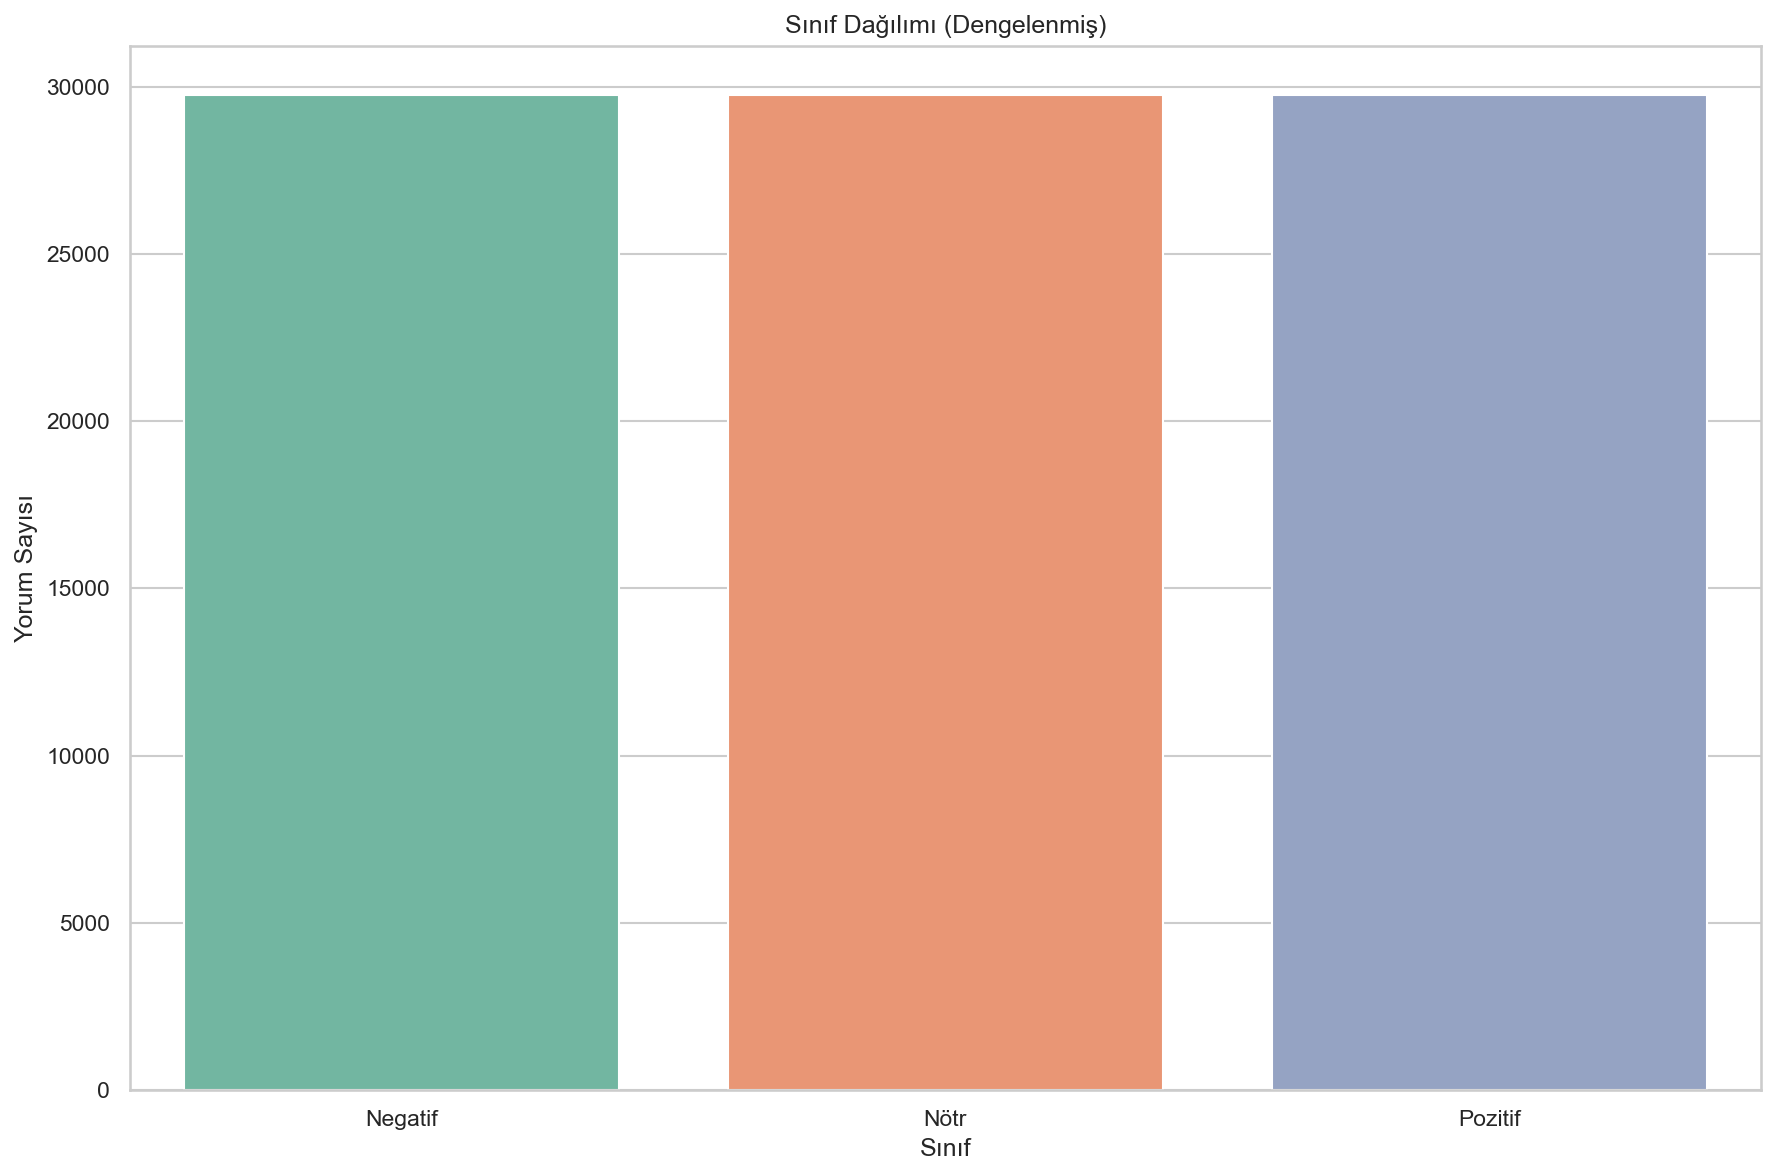

In [2]:
plt.figure()
sns.countplot(data=df, x='class_name', order=['Negatif','Nötr','Pozitif'],
             palette='Set2', hue='class_name', legend=False)
plt.title('Sınıf Dağılımı (Dengelenmiş)')
plt.xlabel('Sınıf')
plt.ylabel('Yorum Sayısı')
plt.tight_layout()
plt.savefig('results/eda_class_distribution.png')
plt.show()

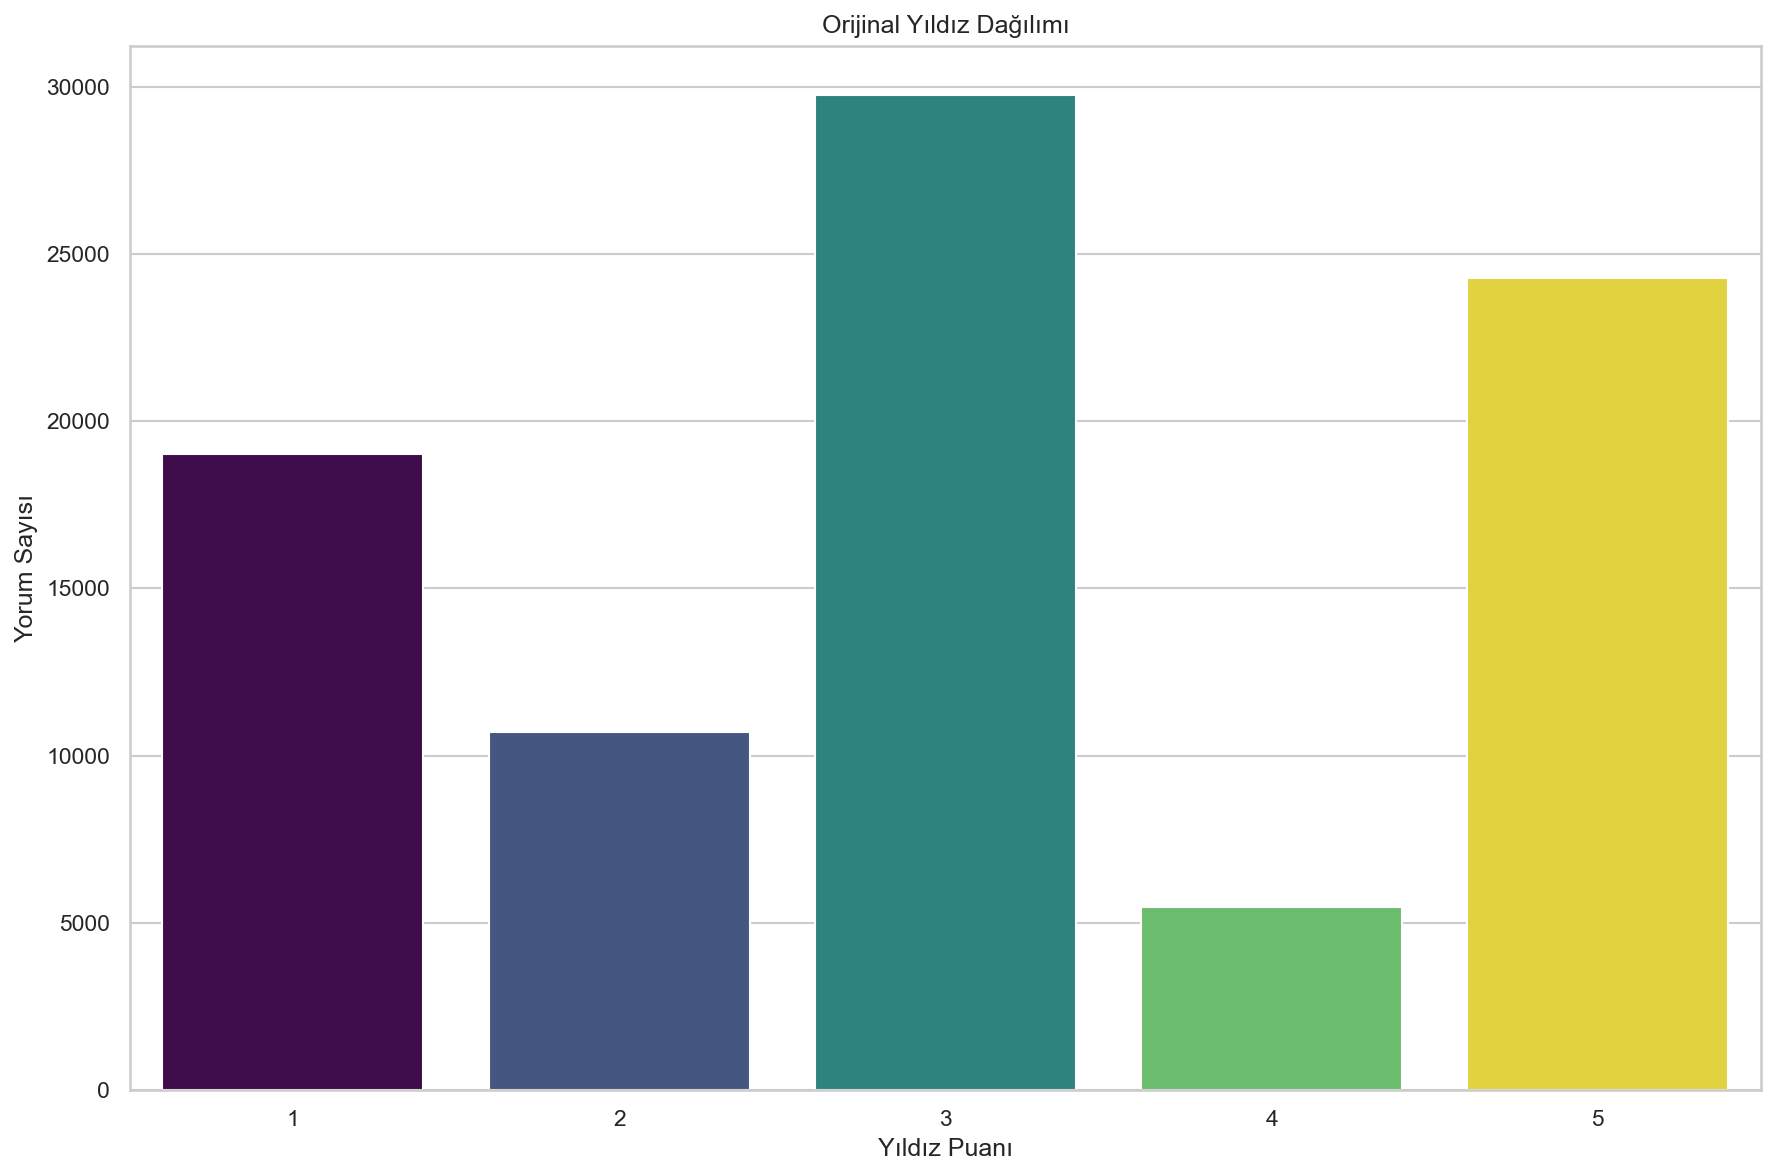

In [3]:
plt.figure()
sns.countplot(data=df, x='Score', palette='viridis', hue='Score', legend=False)
plt.title('Orijinal Yıldız Dağılımı')
plt.xlabel('Yıldız Puanı')
plt.ylabel('Yorum Sayısı')
plt.tight_layout()
plt.savefig('results/eda_star_distribution.png')
plt.show()

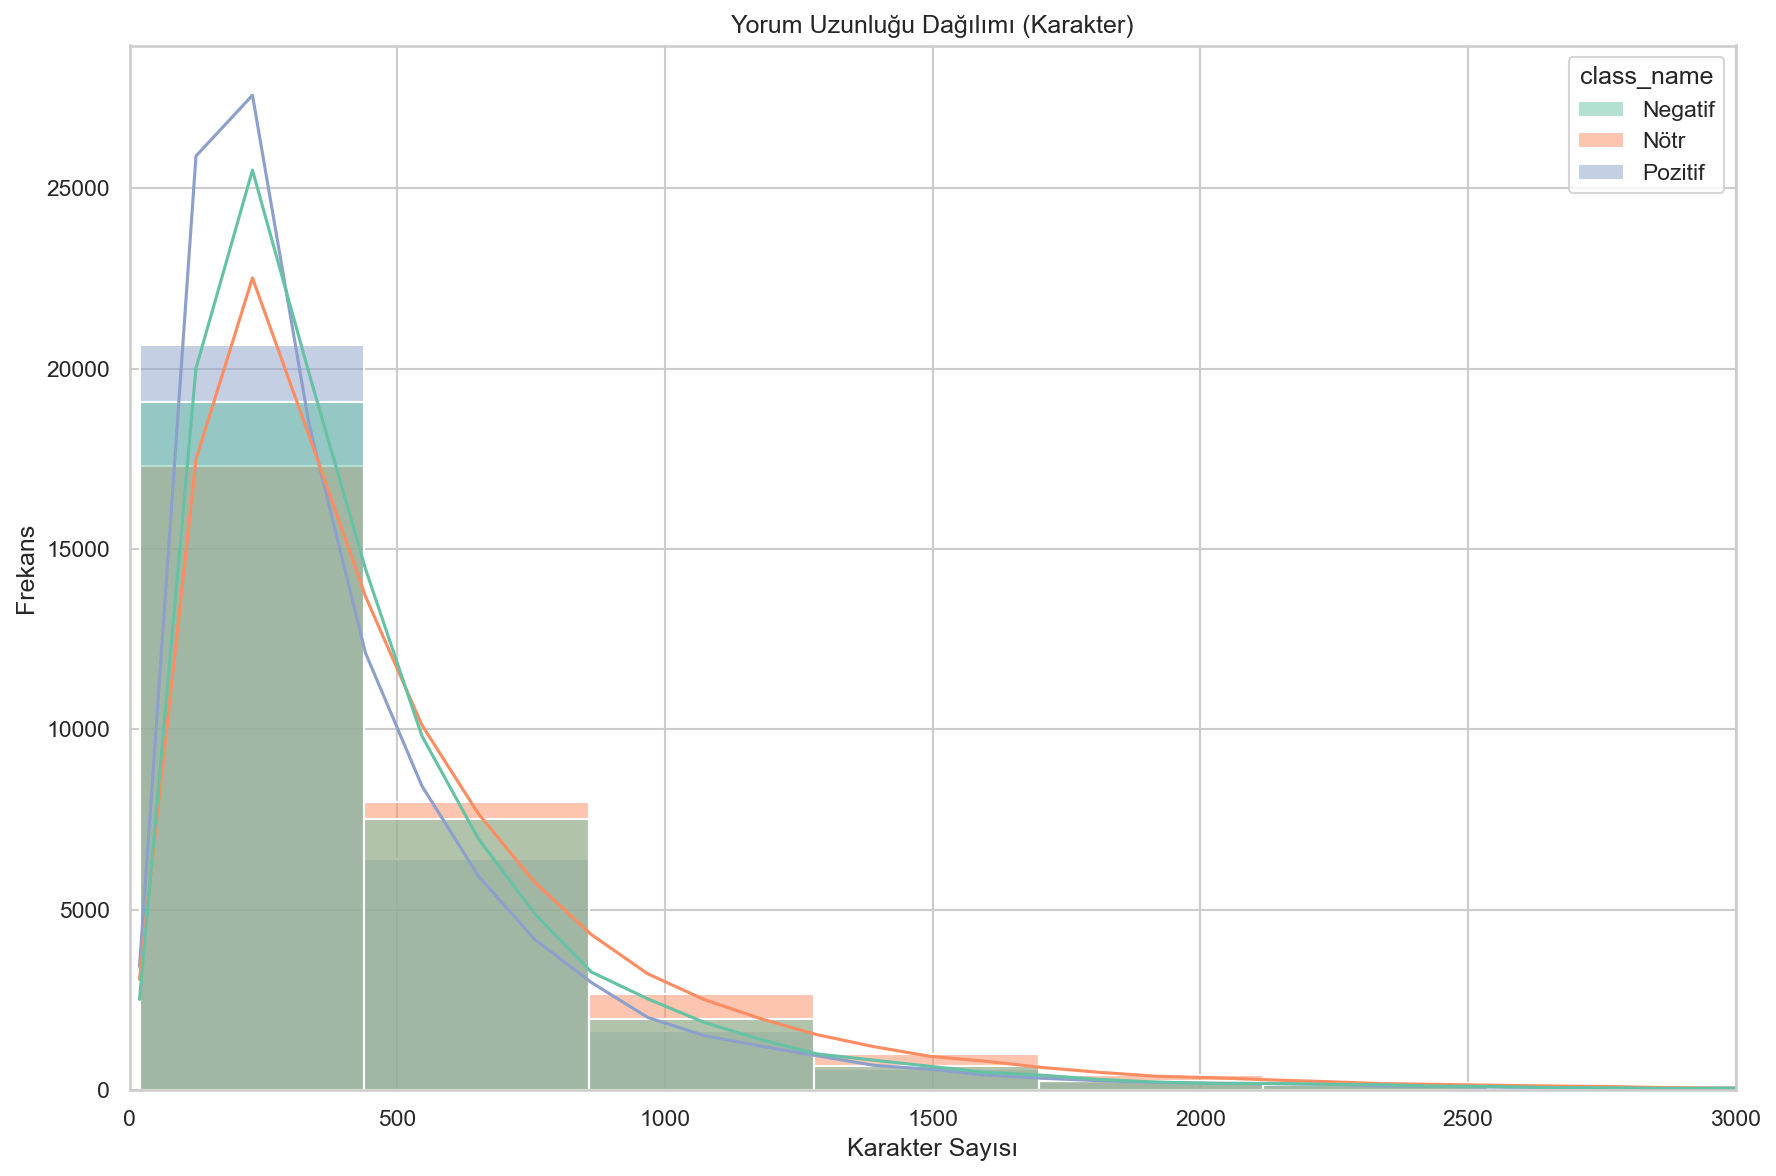

In [4]:
plt.figure()
sns.histplot(data=df, x='review_length', hue='class_name', bins=50,
             kde=True, palette='Set2', alpha=0.5)
plt.xlim(0, 3000)
plt.title('Yorum Uzunluğu Dağılımı (Karakter)')
plt.xlabel('Karakter Sayısı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.savefig('results/eda_review_length.png')
plt.show()

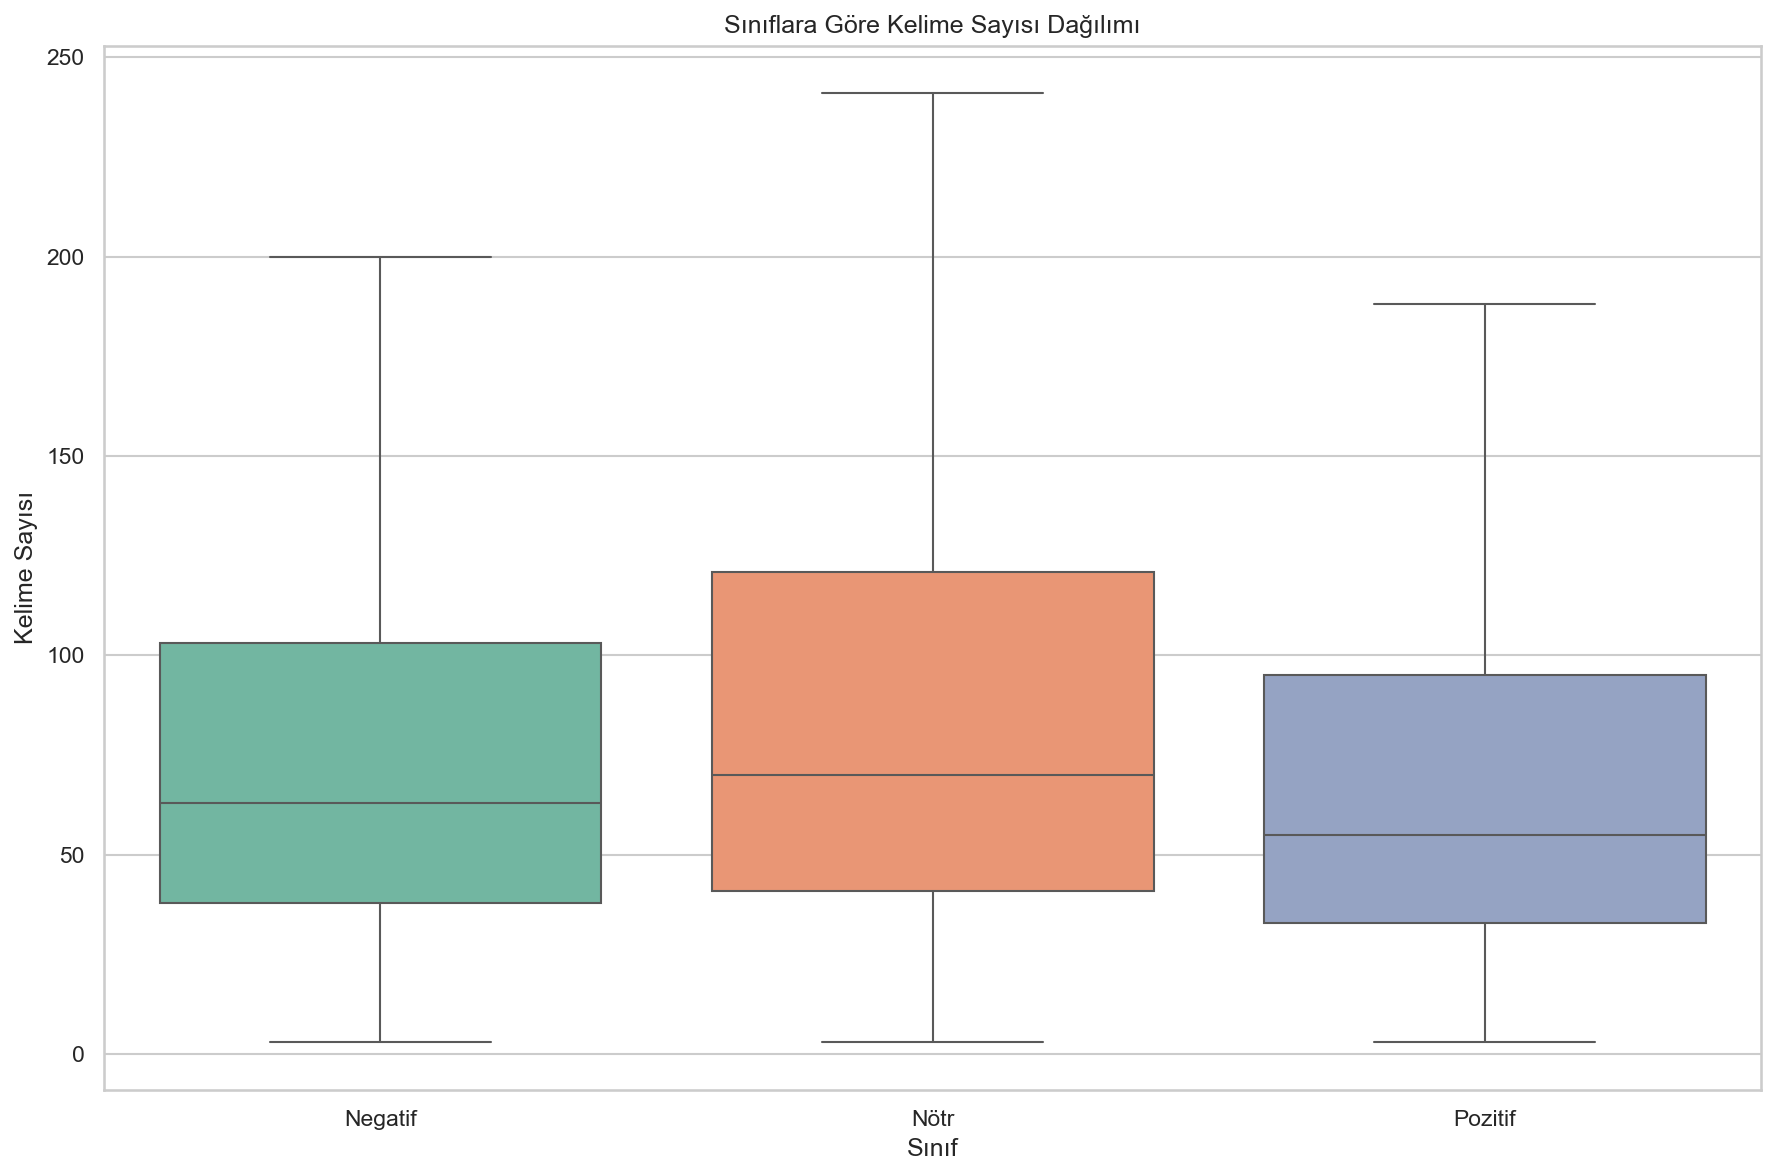

In [5]:
plt.figure()
sns.boxplot(data=df, x='class_name', y='word_count', palette='Set2',
            showfliers=False, hue='class_name', legend=False)
plt.title('Sınıflara Göre Kelime Sayısı Dağılımı')
plt.xlabel('Sınıf')
plt.ylabel('Kelime Sayısı')
plt.tight_layout()
plt.savefig('results/eda_word_count.png')
plt.show()

## 2.2 Metin Analizi

In [6]:
sample_size = min(100000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

# Ham frekansta en sık kelimeler her sınıfta aynı çıkıyor (taste, flavor, coffee...)
# ve bulutlar birbirine benziyordu. Bunun yerine "sınıfa özgü" kelimeleri buluyoruz:
# bir kelimenin o sınıftaki görülme oranı ile diğer sınıflardaki oranının farkı.
ek_stop = {'food','good','great','one','will','just','like','really','product',
           'buy','get','would','also','much','even','br','don','ve','time','use'}
_cv = CountVectorizer(stop_words='english', max_features=4000, min_df=20)
_X = _cv.fit_transform(df_sample['text'])
_vocab = np.array(_cv.get_feature_names_out())
_ys = df_sample['label'].values

def sinifa_ozgu(label, n=100):
    ic = np.asarray(_X[_ys == label].mean(axis=0)).ravel()
    dis = np.asarray(_X[_ys != label].mean(axis=0)).ravel()
    skor = ic - dis
    sonuc = {}
    for i in skor.argsort()[::-1]:
        if skor[i] <= 0:
            break
        w = _vocab[i]
        if w in ek_stop:
            continue
        sonuc[w] = float(skor[i])
        if len(sonuc) >= n:
            break
    return sonuc

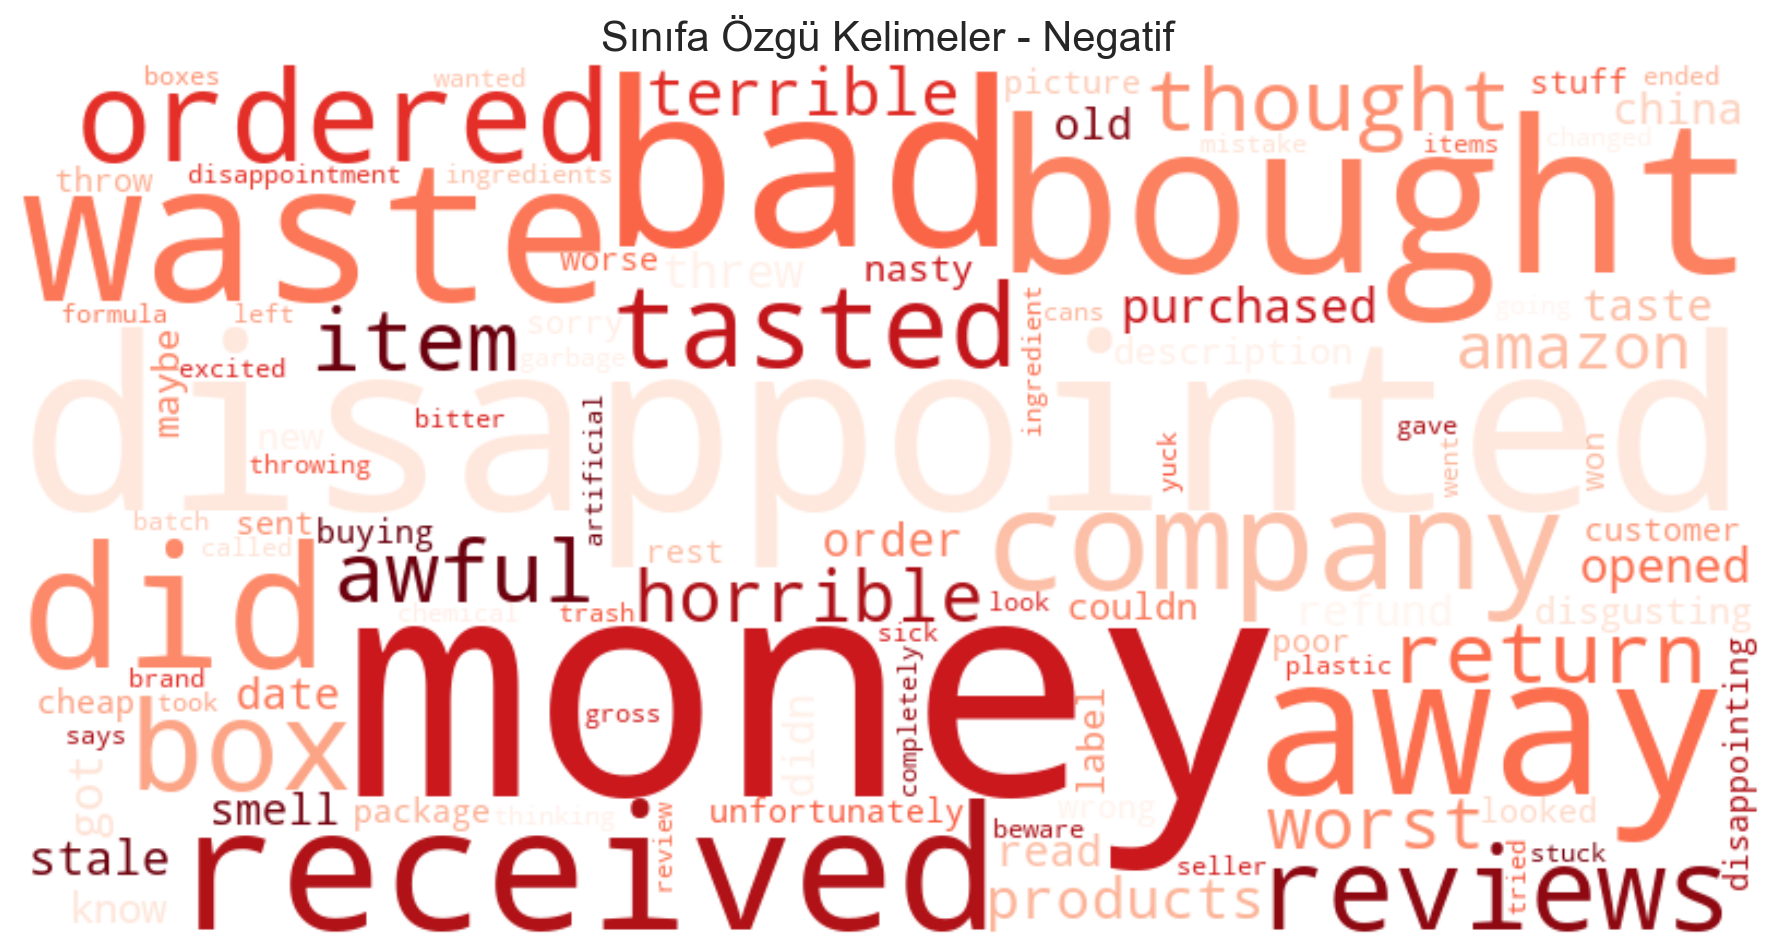

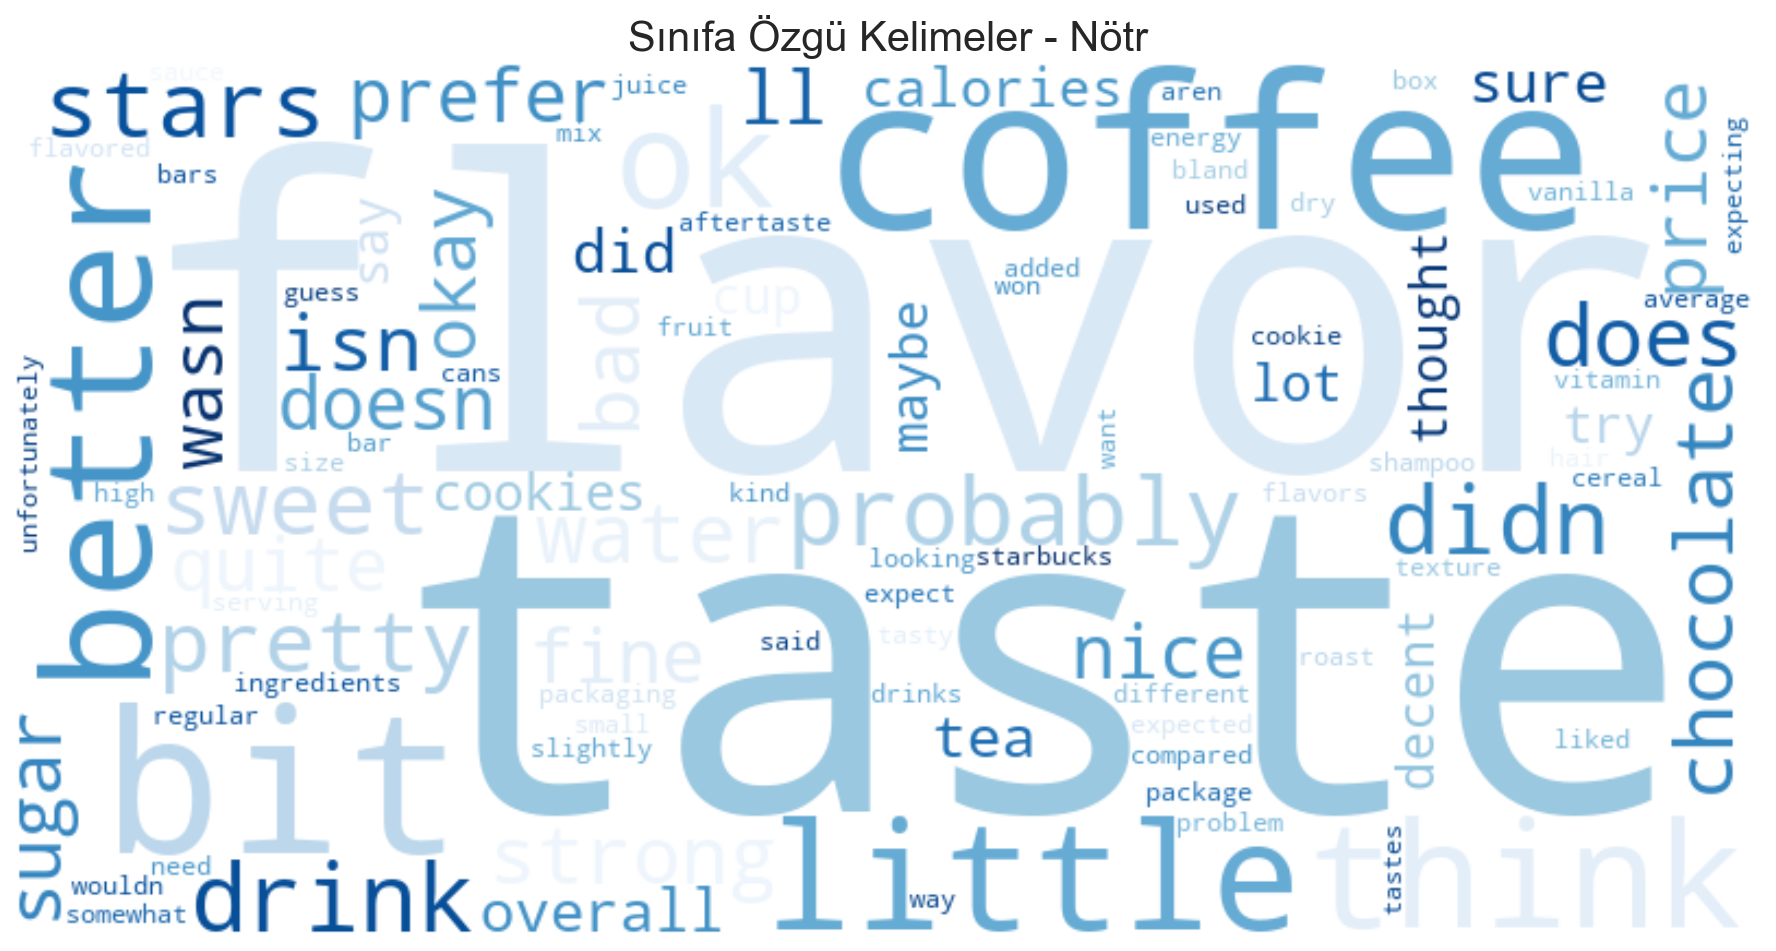

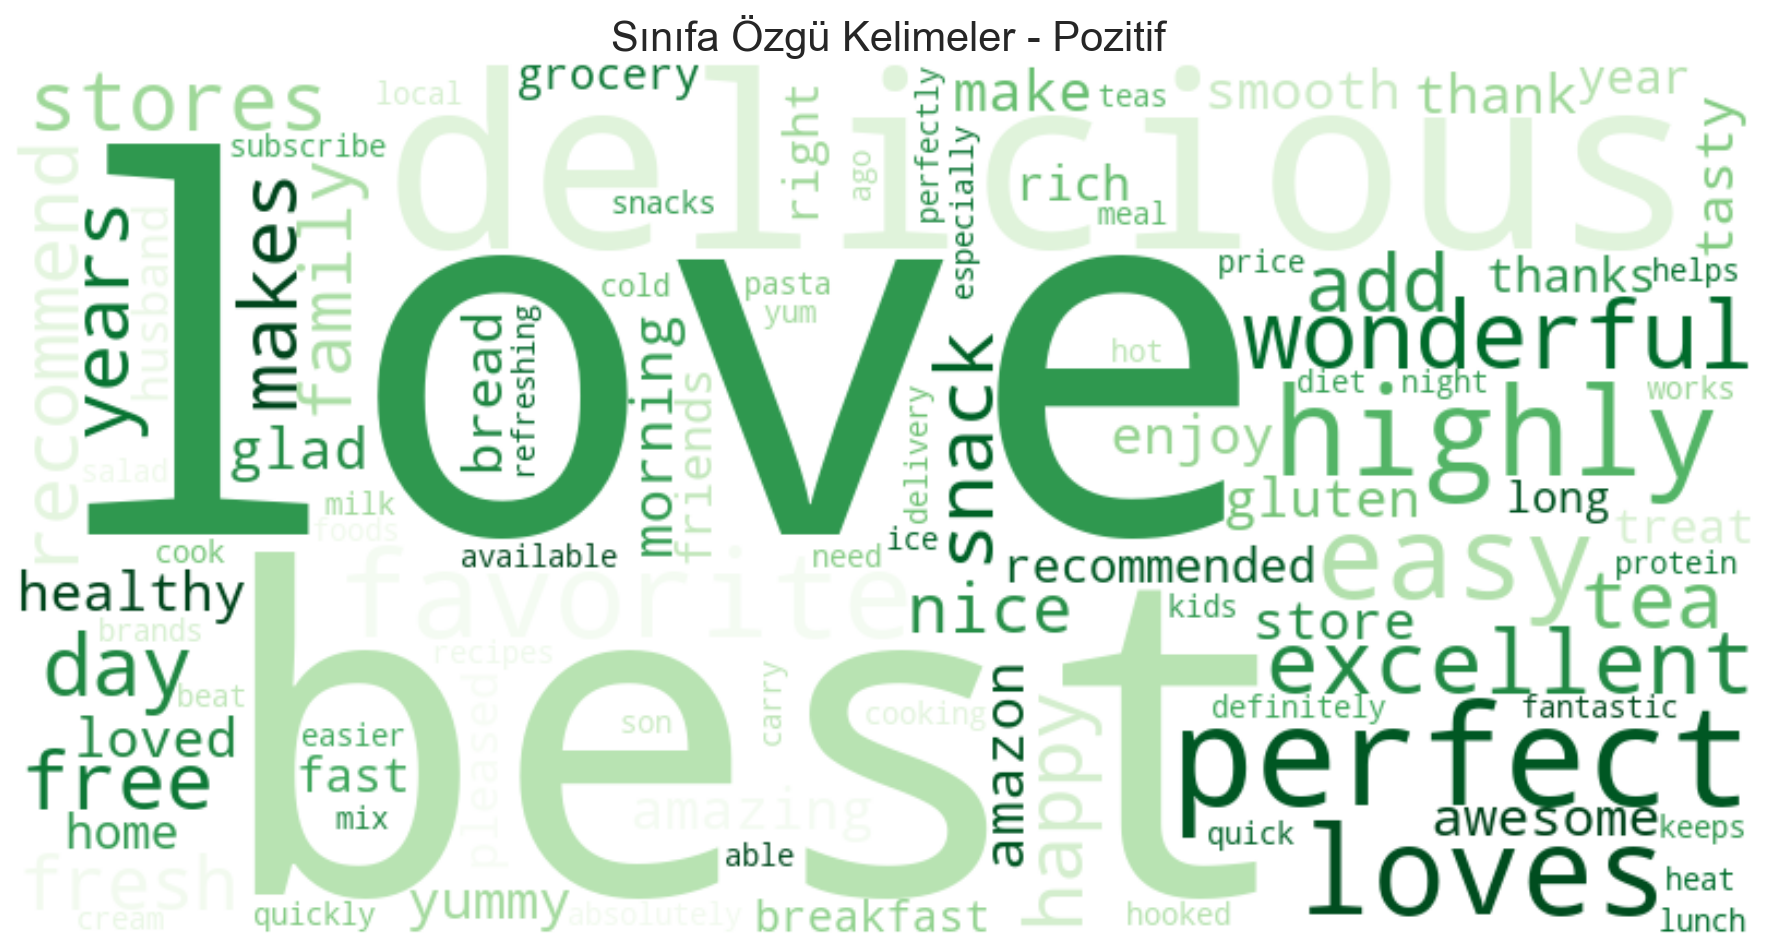

In [7]:
# Sınıfa göre renk: Negatif kırmızımsı, Nötr sarımsı, Pozitif yeşilimsi
renk_haritasi = {0: 'Reds', 1: 'Blues', 2: 'Greens'}
for label, name in class_names.items():
    freqs = sinifa_ozgu(label, 100)
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=renk_haritasi[label], max_words=100)
    wc.generate_from_frequencies(freqs)

    plt.figure()
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Sınıfa Özgü Kelimeler - {name}', fontsize=20)
    plt.tight_layout()
    fname = f'eda_wordcloud_{name.lower().replace("ö","o").replace("ü","u")}.png'
    plt.savefig(os.path.join('results', fname))
    plt.show()

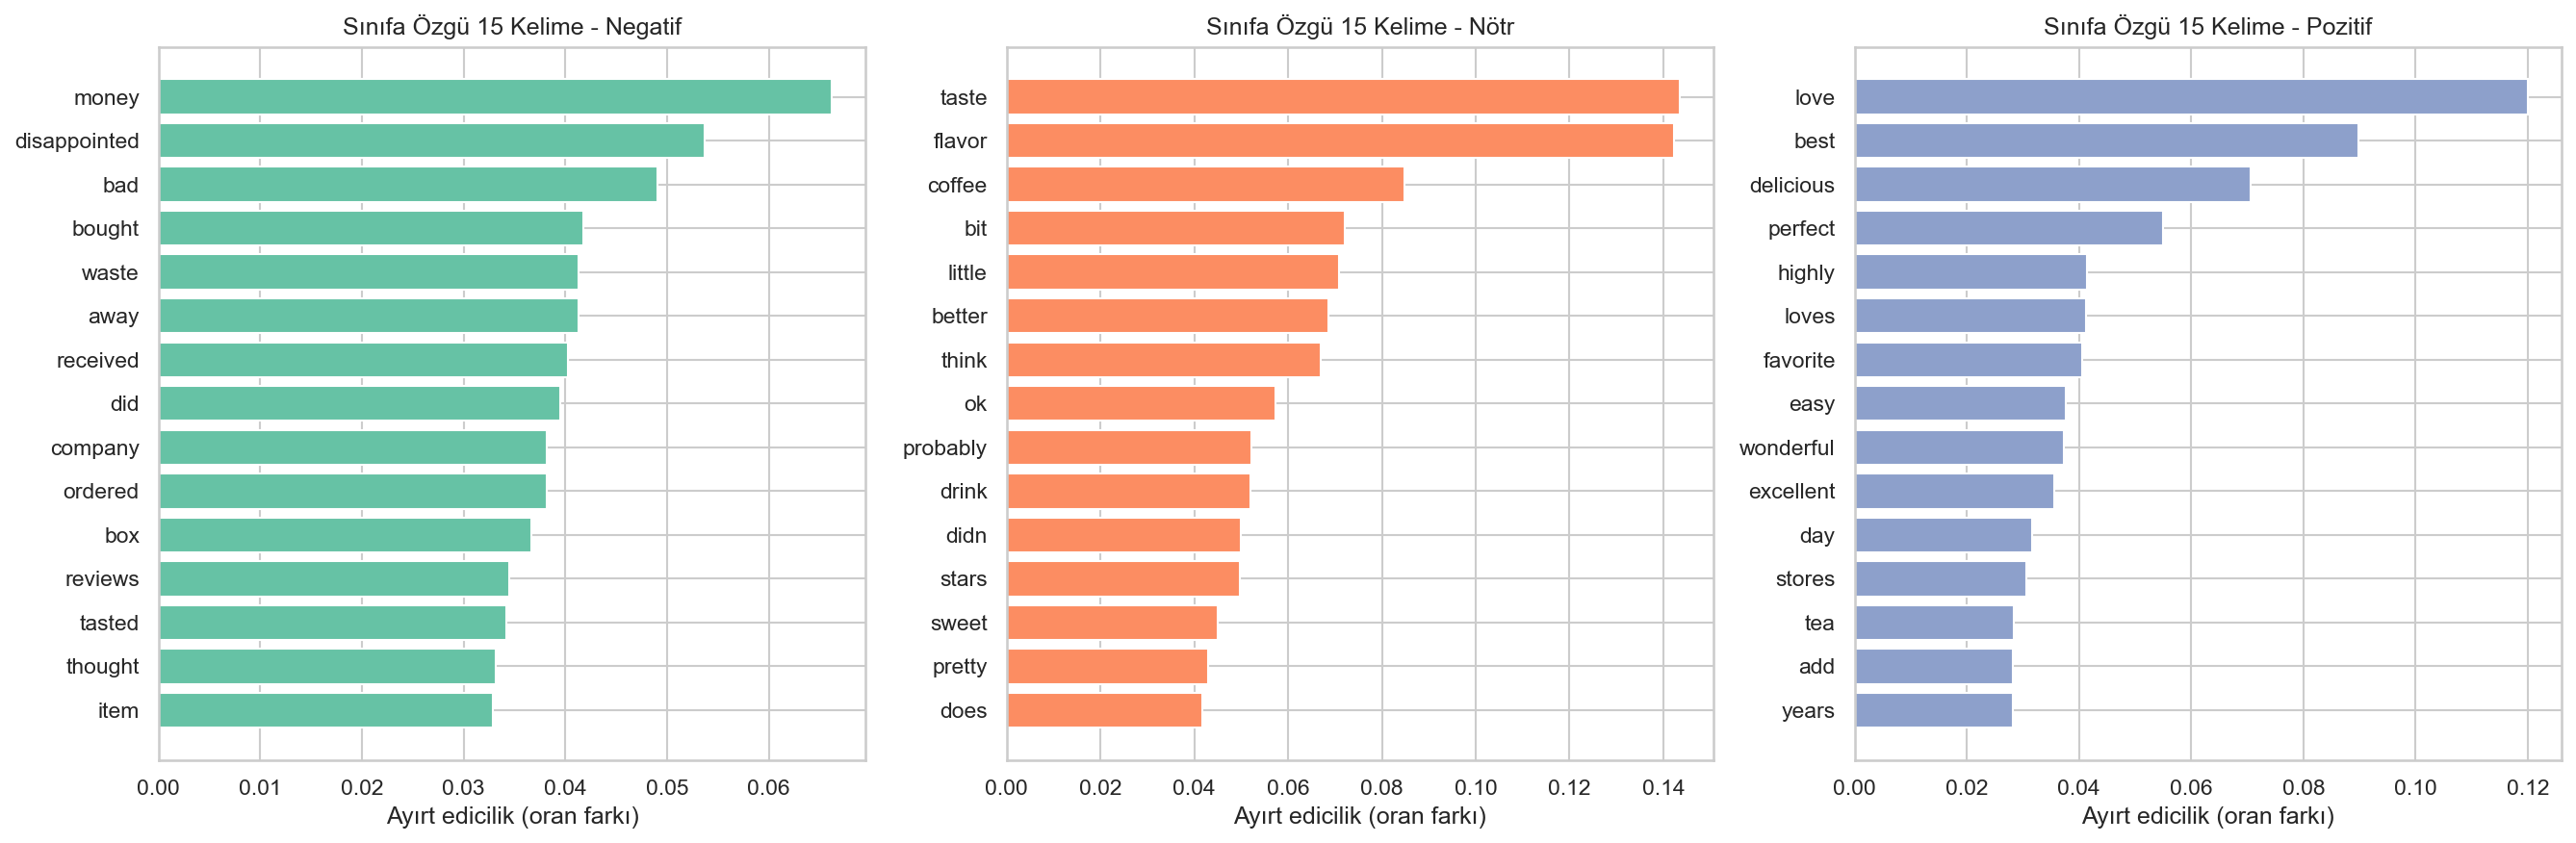

In [8]:
plt.figure(figsize=(18, 6))
for i, (label, name) in enumerate(class_names.items(), 1):
    plt.subplot(1, 3, i)
    d = sinifa_ozgu(label, 15)
    kelimeler = list(d.keys())[::-1]
    degerler = [d[w] for w in kelimeler]
    plt.barh(kelimeler, degerler, color=sns.color_palette('Set2')[i-1])
    plt.title(f'Sınıfa Özgü 15 Kelime - {name}')
    plt.xlabel('Ayırt edicilik (oran farkı)')
plt.tight_layout()
plt.savefig('results/eda_top_words.png')
plt.show()

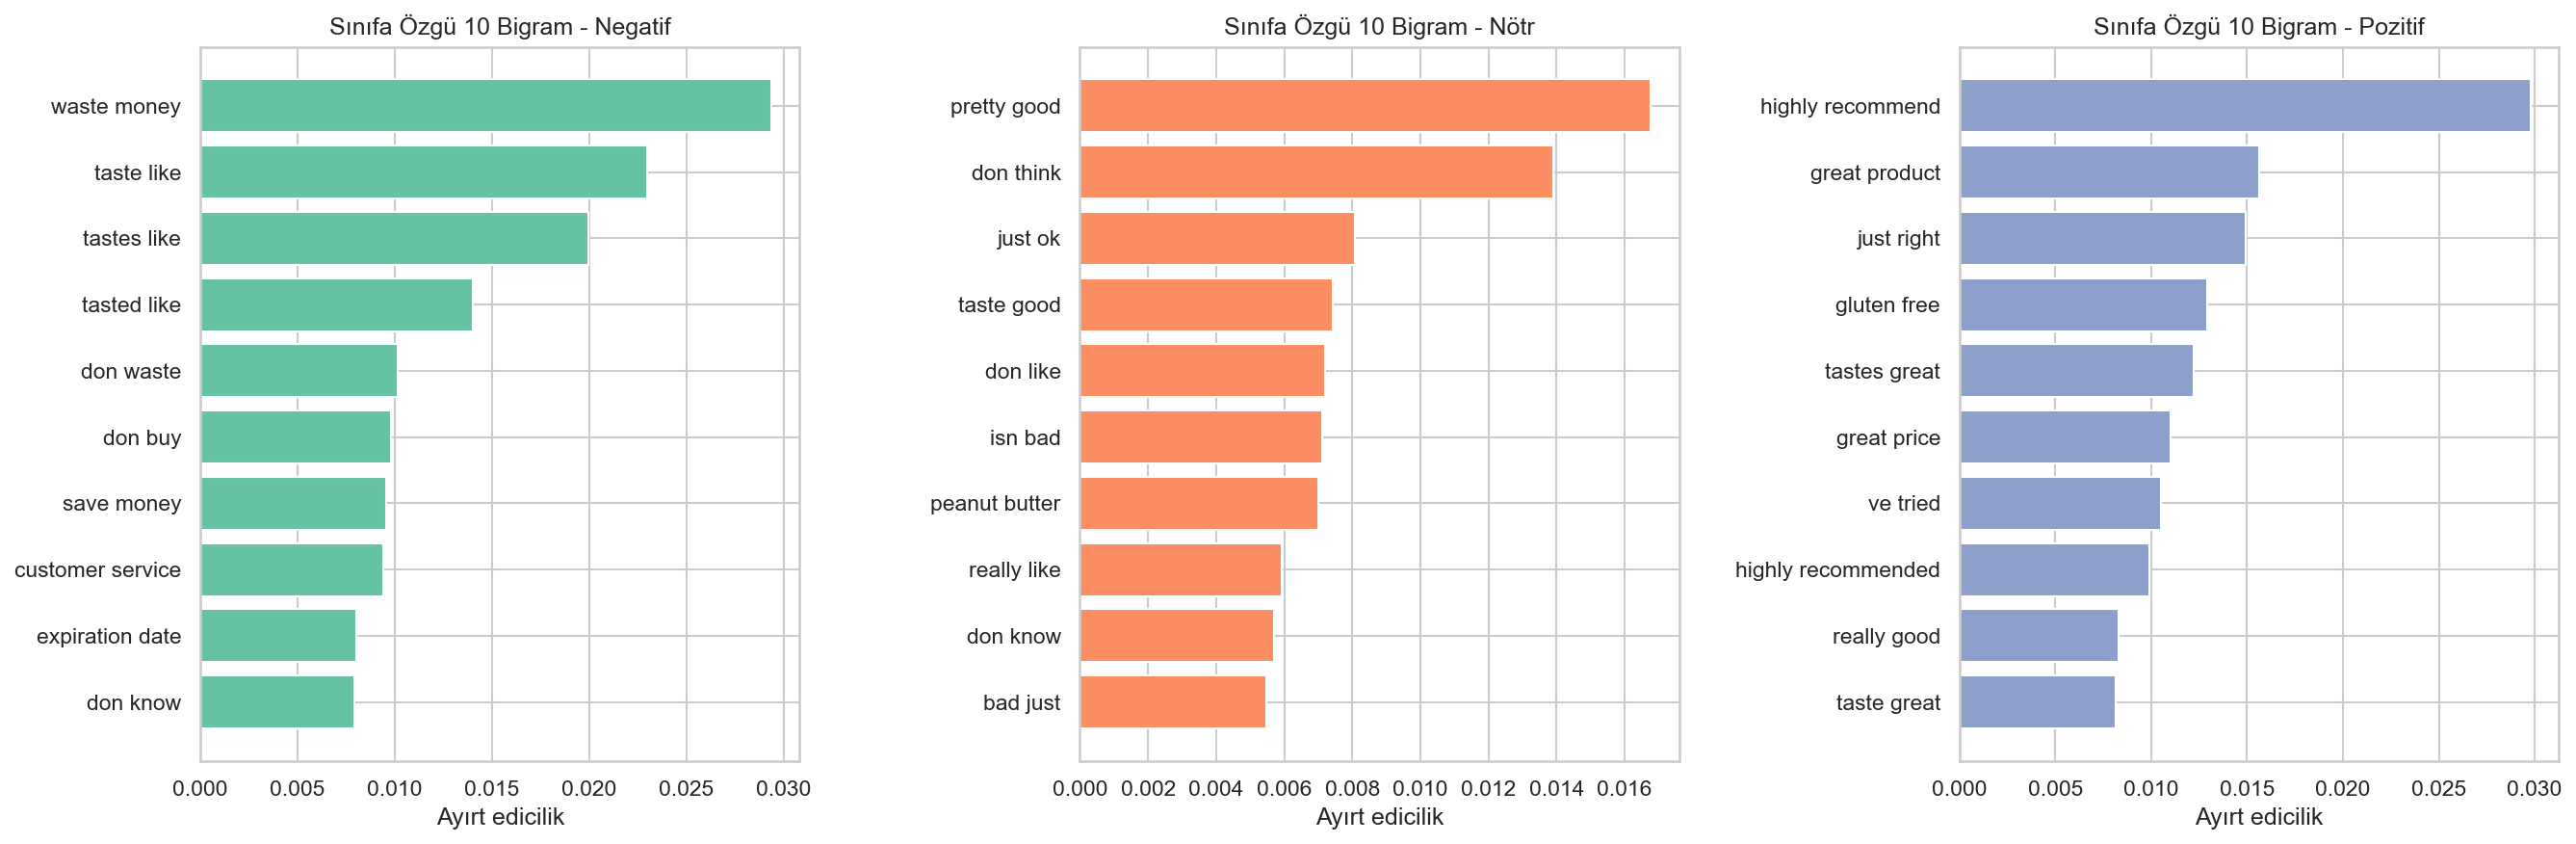

In [9]:
# Bigram'larda da sınıfa özgü (ayırt edici) ikilileri gösteriyoruz.
_cvb = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=3000, min_df=10)
_Xb = _cvb.fit_transform(df_sample['text'])
_vb = np.array(_cvb.get_feature_names_out())

plt.figure(figsize=(18, 6))
for i, (label, name) in enumerate(class_names.items(), 1):
    plt.subplot(1, 3, i)
    ic = np.asarray(_Xb[_ys == label].mean(axis=0)).ravel()
    dis = np.asarray(_Xb[_ys != label].mean(axis=0)).ravel()
    skor = ic - dis
    order = skor.argsort()[-10:][::-1][::-1]
    kelimeler = [_vb[j] for j in order]
    degerler = [skor[j] for j in order]
    plt.barh(kelimeler, degerler, color=sns.color_palette('Set2')[i-1])
    plt.title(f'Sınıfa Özgü 10 Bigram - {name}')
    plt.xlabel('Ayırt edicilik')
plt.tight_layout()
plt.savefig('results/eda_bigrams.png')
plt.show()

## 2.3 Amazon'a Özgü Analizler

C:\Users\furkn\AppData\Local\Temp\ipykernel_22900\1183713129.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='help_bucket', y='label', data=help_sent, palette='coolwarm')


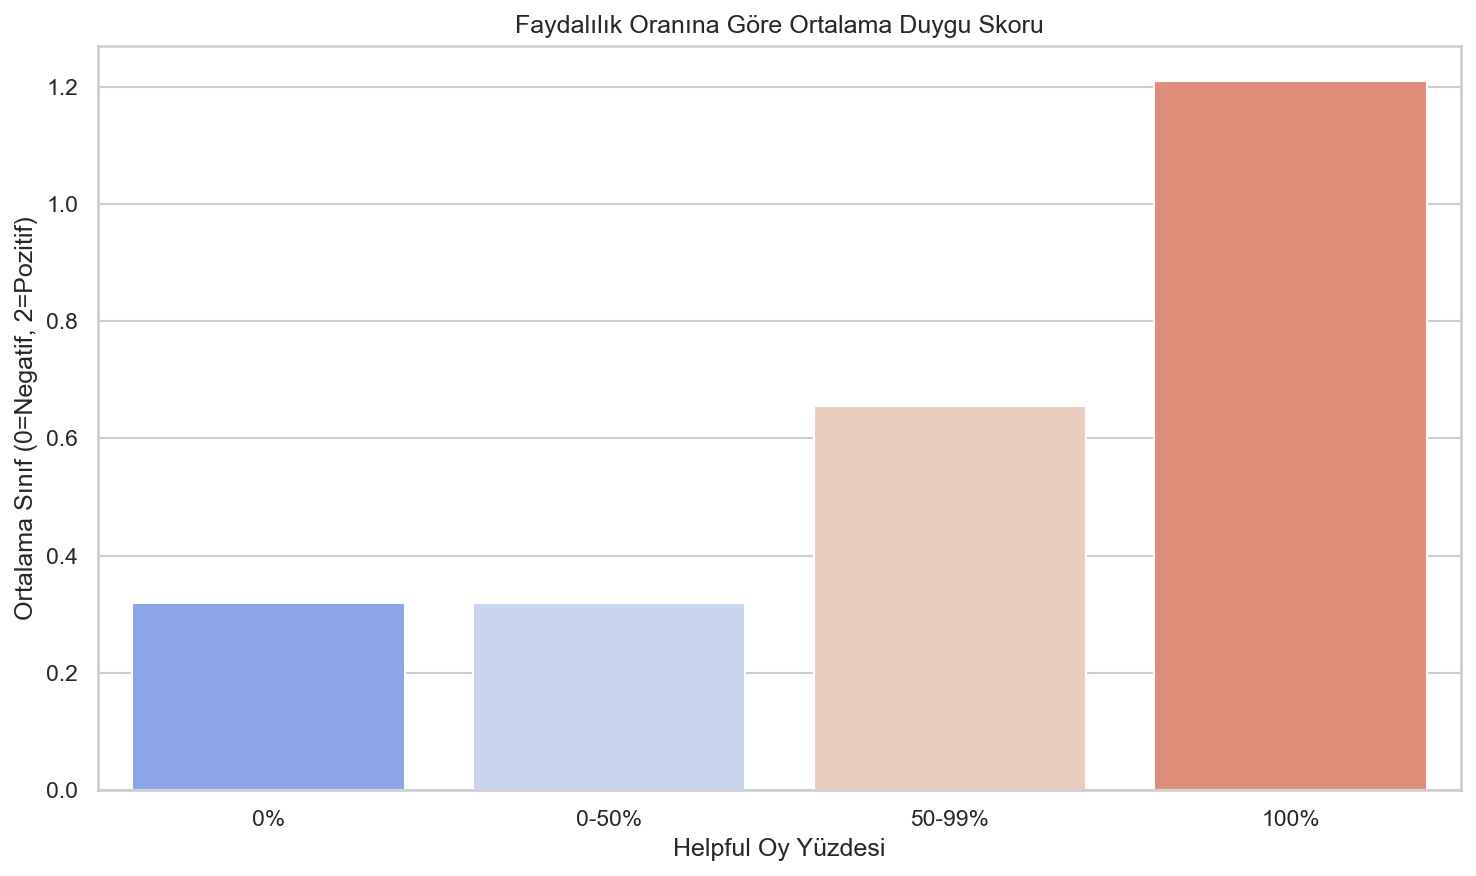

In [10]:
# Helpfulness (Faydalılık) Analizi
df['help_ratio'] = df.apply(
    lambda r: r['HelpfulnessNumerator']/r['HelpfulnessDenominator']
              if r['HelpfulnessDenominator'] > 0 else None, axis=1)

df_help = df[df['HelpfulnessDenominator'] >= 5].copy()
df_help['help_bucket'] = pd.cut(df_help['help_ratio'],
    bins=[-0.01, 0.0, 0.5, 0.99, 1.01],
    labels=['0%', '0-50%', '50-99%', '100%'])

help_sent = df_help.groupby('help_bucket', observed=True)['label'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='help_bucket', y='label', data=help_sent, palette='coolwarm')
plt.title('Faydalılık Oranına Göre Ortalama Duygu Skoru')
plt.xlabel('Helpful Oy Yüzdesi')
plt.ylabel('Ortalama Sınıf (0=Negatif, 2=Pozitif)')
plt.tight_layout()
plt.savefig('results/eda_helpfulness.png')
plt.show()

<Figure size 1500x900 with 0 Axes>

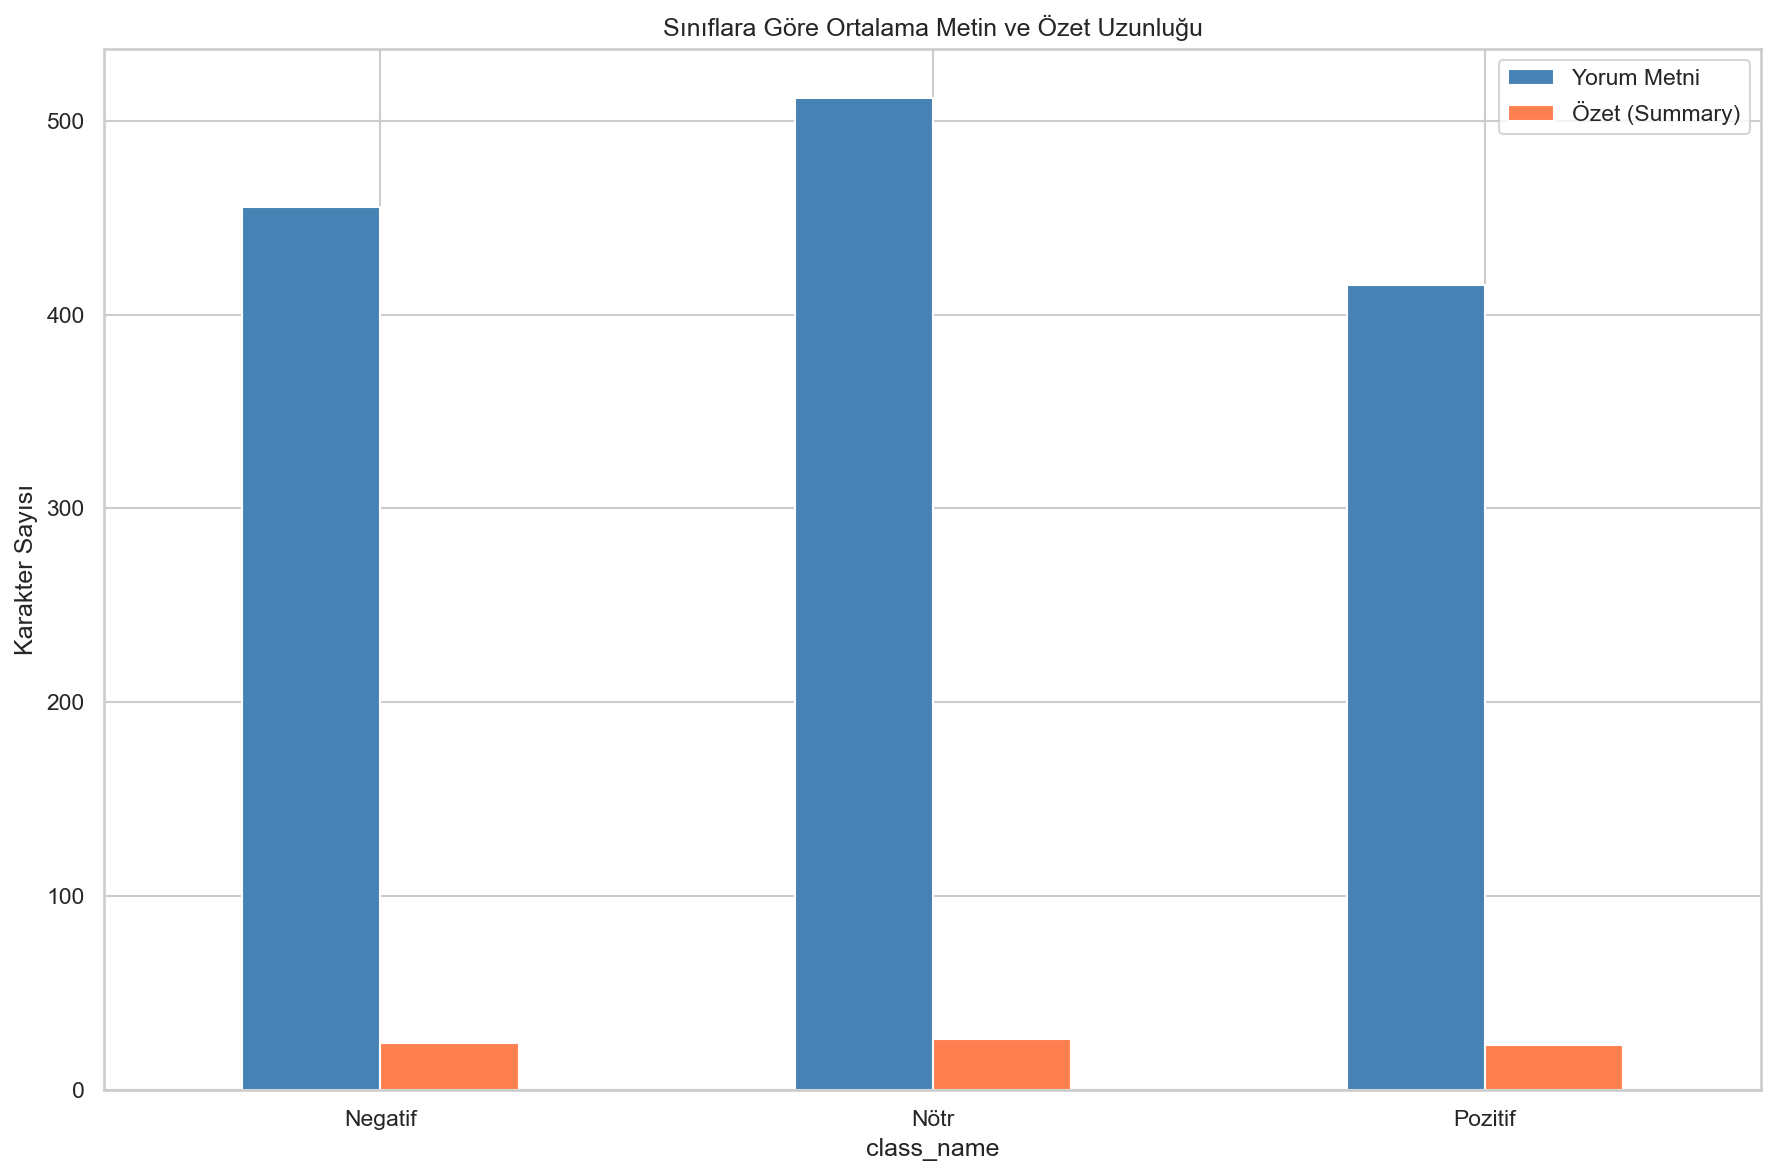

In [11]:
# Summary vs Text Uzunluk Karşılaştırması
df['summary'] = df['summary'].astype(str)
df['summary_len'] = df['summary'].str.len()

plt.figure(figsize=(10, 6))
summary_means = df.groupby('class_name')[['review_length','summary_len']].mean()
summary_means.plot(kind='bar', rot=0, color=['steelblue','coral'])
plt.title('Sınıflara Göre Ortalama Metin ve Özet Uzunluğu')
plt.ylabel('Karakter Sayısı')
plt.legend(['Yorum Metni', 'Özet (Summary)'])
plt.tight_layout()
plt.savefig('results/eda_summary_vs_text.png')
plt.show()

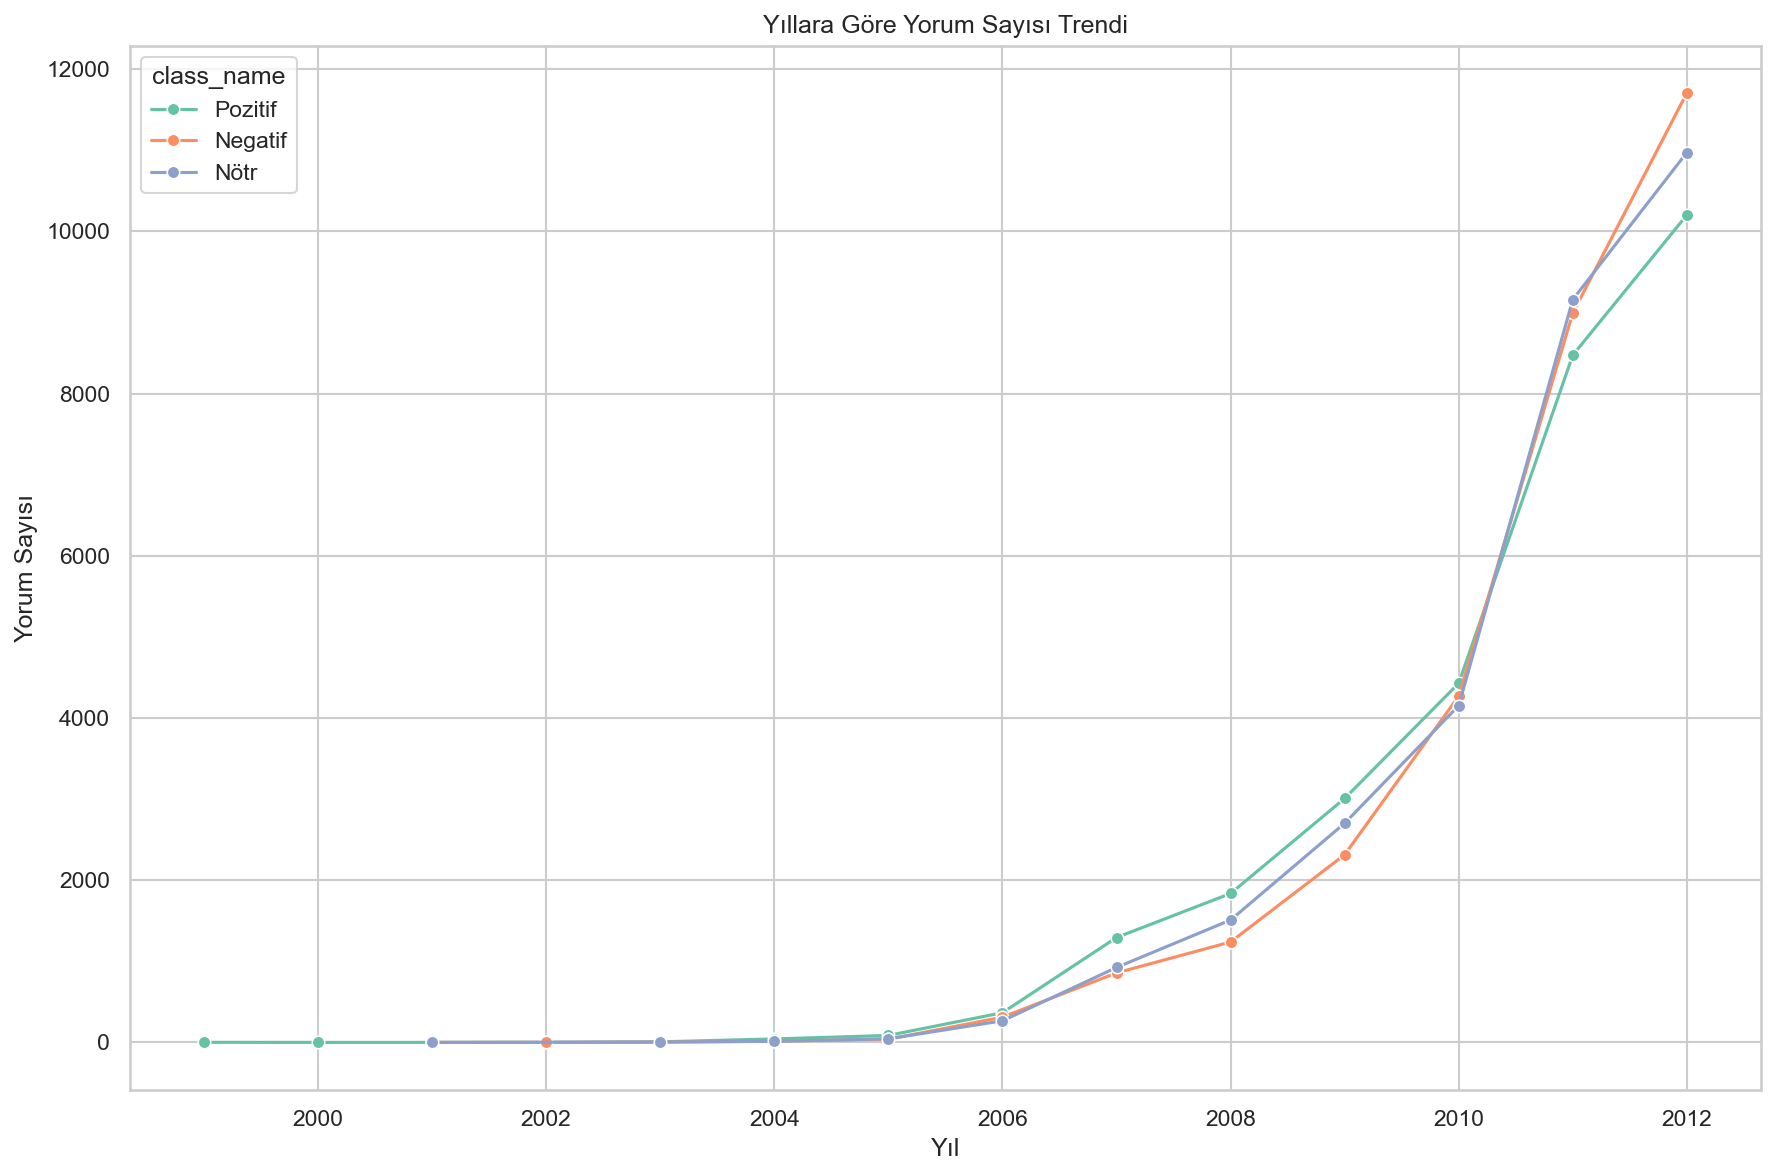

In [12]:
# Yıllara Göre Yorum Trendi
plt.figure()
yearly = df.groupby(['year','class_name']).size().reset_index(name='count')
sns.lineplot(data=yearly, x='year', y='count', hue='class_name',
             marker='o', palette='Set2')
plt.title('Yıllara Göre Yorum Sayısı Trendi')
plt.xlabel('Yıl')
plt.ylabel('Yorum Sayısı')
plt.tight_layout()
plt.savefig('results/eda_time_trend.png')
plt.show()

## 2.4 Özet İstatistikler

In [13]:
print('\n' + '='*50)
print('SINIFLARA GÖRE ÖZET İSTATİSTİKLER'.center(50))
print('='*50)
summary = df.groupby('class_name')['word_count'].agg(['mean','std','min','max'])
print(summary)
print('='*50)


        SINIFLARA GÖRE ÖZET İSTATİSTİKLER         
                 mean        std  min   max
class_name                                 
Negatif     84.463906  78.045425    3  2093
Nötr        95.471905  87.663678    3  3409
Pozitif     77.702984  77.131047    3  1787


## 2.5 Konu Modellemesi (LDA)
Denetimsiz (unsupervised) **Latent Dirichlet Allocation** ile yorumlardaki gizli konuları keşfediyoruz.

In [14]:
from sklearn.decomposition import LatentDirichletAllocation

print('LDA için 100.000 rastgele örnek seçiliyor...')
df_lda = df.sample(n=min(100000, len(df)), random_state=42)
texts = df_lda['text'].astype(str).values

print('CountVectorizer oluşturuluyor...')
tf_vec = CountVectorizer(max_df=0.95, min_df=2, max_features=10000,
                         stop_words='english')
tf_matrix = tf_vec.fit_transform(texts)

print('LDA modeli eğitiliyor...')
lda = LatentDirichletAllocation(n_components=5, max_iter=10,
    learning_method='online', random_state=42, n_jobs=-1)
lda.fit(tf_matrix)

print('\n--- Bulunan Konuların En Önemli 10 Kelimesi ---')
feat_names = tf_vec.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    top = topic.argsort()[:-11:-1]
    words = [feat_names[i] for i in top]
    print(f'Topic {idx+1}: {" | ".join(words)}')

try:
    import pyLDAvis
    import pyLDAvis.lda_model
    pyLDAvis.enable_notebook()
    panel = pyLDAvis.lda_model.prepare(lda, tf_matrix, tf_vec)
    pyLDAvis.save_html(panel, 'results/lda_interactive_plot.html')
    print('\nLDA grafiği results/lda_interactive_plot.html olarak kaydedildi!')
    display(panel)
except ImportError:
    print('pyLDAvis kurulu değil, interaktif grafik atlanıyor.')

LDA için 100.000 rastgele örnek seçiliyor...
CountVectorizer oluşturuluyor...


LDA modeli eğitiliyor...



--- Bulunan Konuların En Önemli 10 Kelimesi ---
Topic 1: like | taste | flavor | good | just | chocolate | really | don | love | try
Topic 2: food | ingredients | eat | dog | cat | chicken | rice | salt | corn | cheese
Topic 3: sugar | taste | water | like | drink | product | milk | flavor | mix | use
Topic 4: coffee | tea | cup | like | flavor | good | green | taste | cups | strong
Topic 5: product | amazon | price | box | time | just | buy | order | store | great
pyLDAvis kurulu değil, interaktif grafik atlanıyor.


## 2.6 Ek Keşifsel Analizler
Korelasyon matrisi, saatlik/günlük duygu trendi, en aktif kullanıcılar ve Zipf yasası.

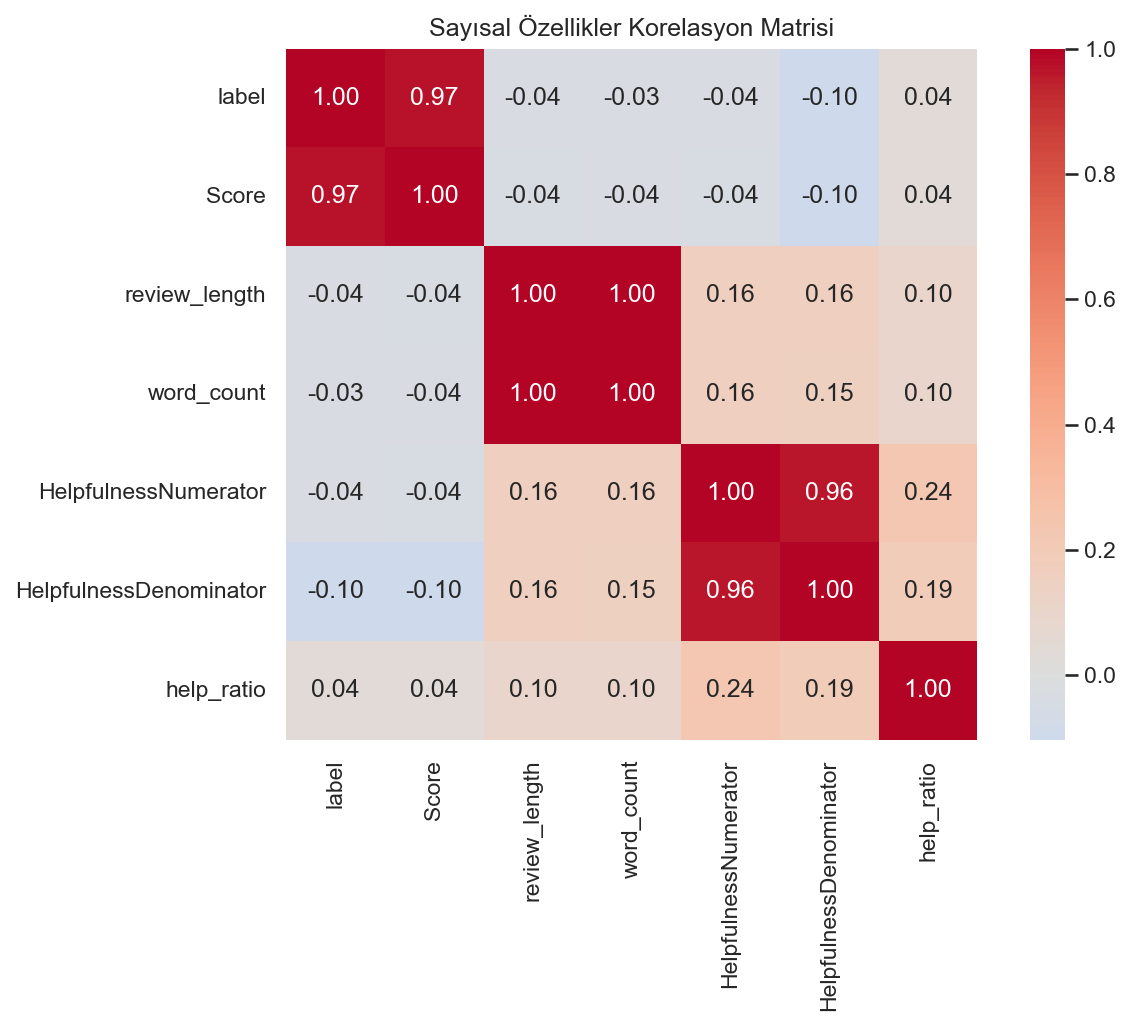

In [15]:
# === EK ANALİZ: Korelasyon Matrisi ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
dfc = pd.read_csv('data/reviews_cleaned.csv')
dfc['text'] = dfc['text'].astype(str)
dfc['review_length'] = dfc['text'].str.len()
dfc['word_count'] = dfc['text'].str.split().apply(len)
dfc['help_ratio'] = (dfc['HelpfulnessNumerator'] / dfc['HelpfulnessDenominator'].replace(0, np.nan)).fillna(0)
corr_cols = ['label','Score','review_length','word_count',
             'HelpfulnessNumerator','HelpfulnessDenominator','help_ratio']
corr = dfc[corr_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Sayısal Özellikler Korelasyon Matrisi')
plt.tight_layout(); plt.savefig('results/eda_correlation.png'); plt.show()

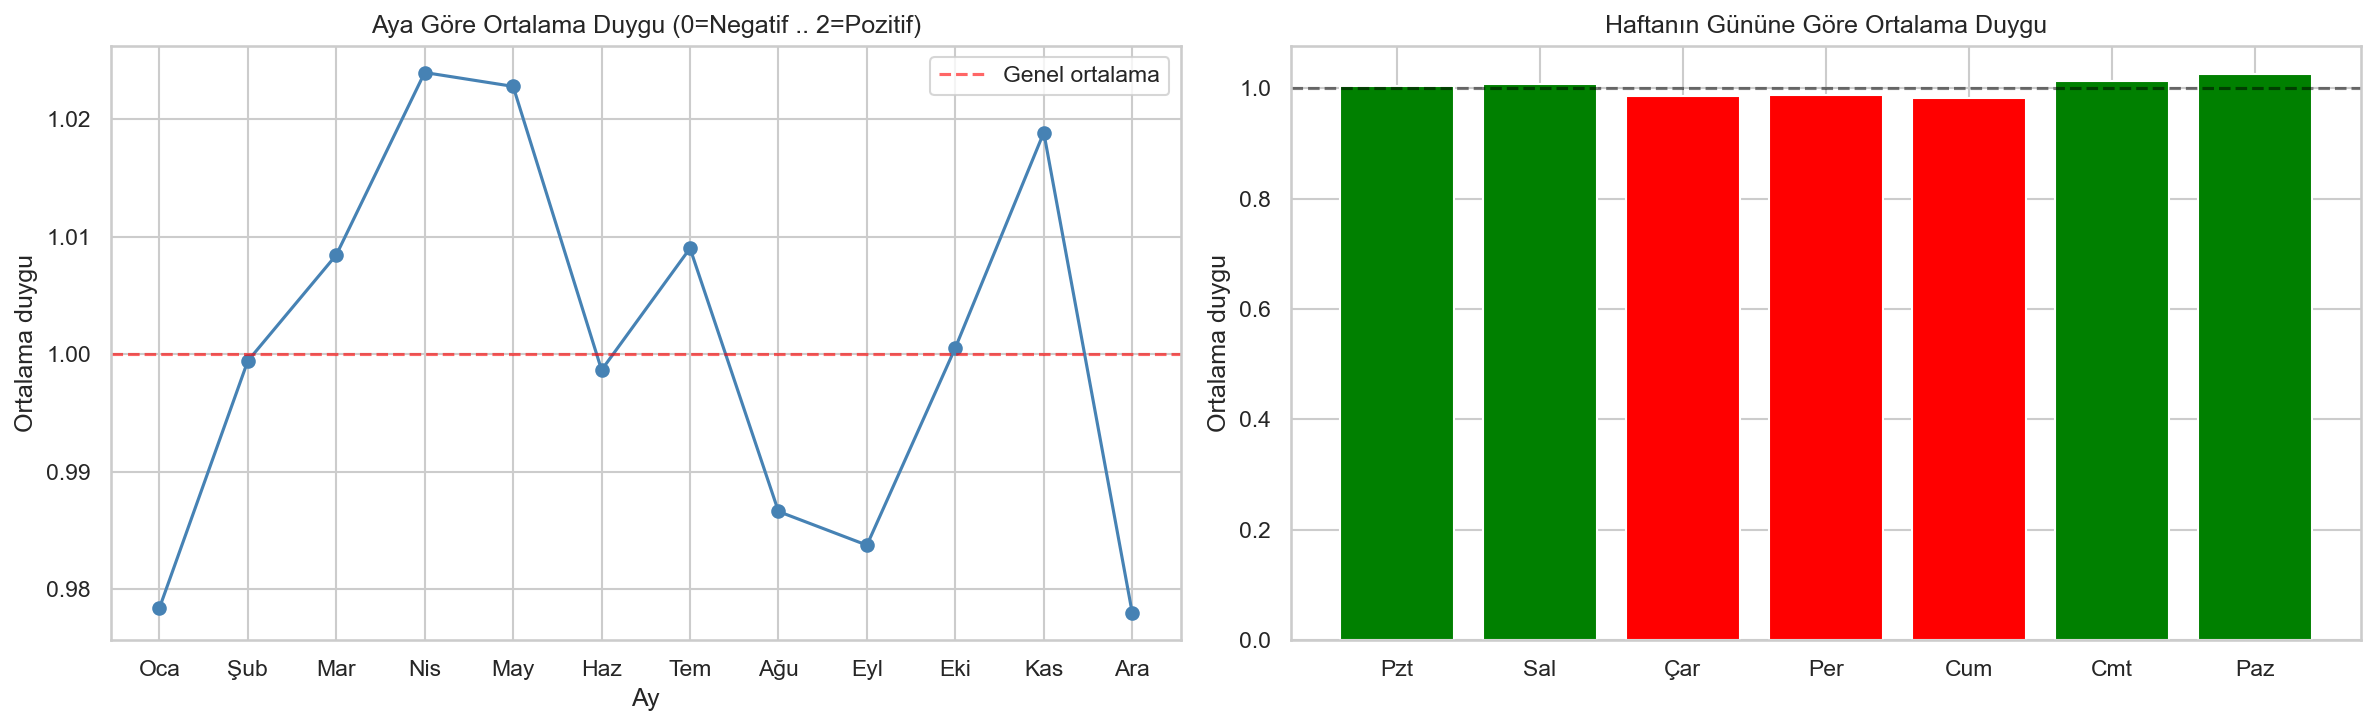

In [16]:
# === EK ANALİZ: Aylık ve Günlük Duygu Trendi ===
# Not: Veri kümesindeki Time alanı yalnızca tarihi tutar (saat bilgisi her zaman 00:00),
# bu nedenle saat bazlı analiz anlamlı değildir; aylık ve haftalık eğilime bakıyoruz.
dfc['timestamp'] = pd.to_datetime(dfc['Time'], unit='s')
dfc['ay'] = dfc['timestamp'].dt.month
dfc['dow'] = dfc['timestamp'].dt.dayofweek
aylar = ['Oca','Şub','Mar','Nis','May','Haz','Tem','Ağu','Eyl','Eki','Kas','Ara']
gun = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']
ort = dfc['label'].mean()
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
aylik = dfc.groupby('ay')['label'].mean()
ax[0].plot([aylar[i-1] for i in aylik.index], aylik.values, marker='o', color='steelblue')
ax[0].axhline(ort, color='red', ls='--', alpha=0.6, label='Genel ortalama')
ax[0].set_title('Aya Göre Ortalama Duygu (0=Negatif .. 2=Pozitif)')
ax[0].set_xlabel('Ay'); ax[0].set_ylabel('Ortalama duygu'); ax[0].legend()
daily = dfc.groupby('dow')['label'].mean()
renk = ['green' if v >= ort else 'red' for v in daily.values]
ax[1].bar([gun[i] for i in daily.index], daily.values, color=renk)
ax[1].axhline(ort, color='black', ls='--', alpha=0.5)
ax[1].set_title('Haftanın Gününe Göre Ortalama Duygu'); ax[1].set_ylabel('Ortalama duygu')
plt.tight_layout(); plt.savefig('results/eda_temporal_hour_day.png'); plt.show()

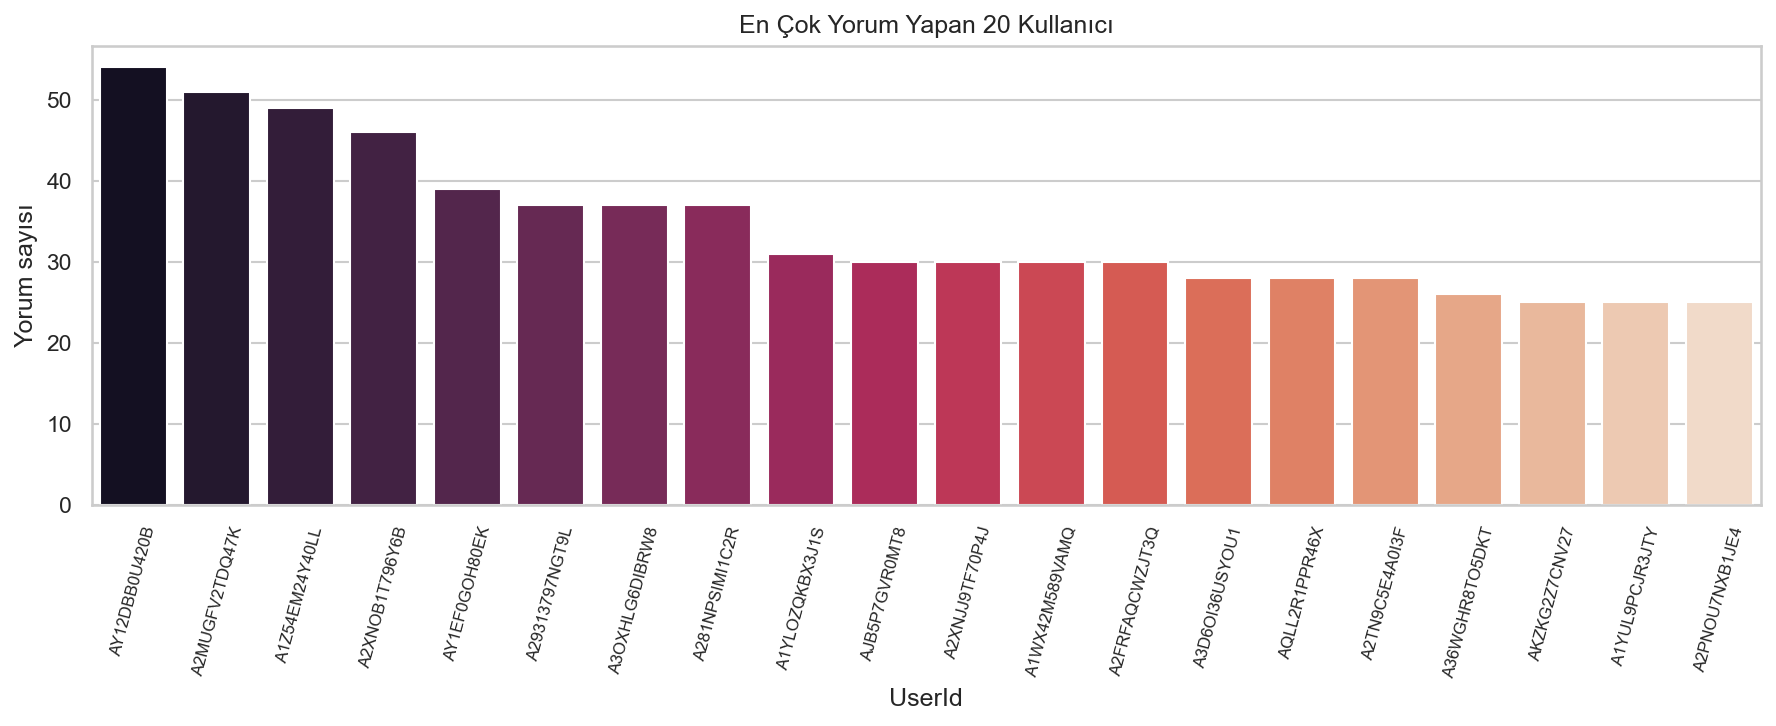

En aktif kullanıcı: AY12DBB0U420B -> 54 yorum


In [17]:
# === EK ANALİZ: En Aktif Kullanıcılar (yoğun yorumcu / spam göstergesi) ===
top_users = dfc['UserId'].value_counts().head(20)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_users.index, y=top_users.values, palette='rocket',
            hue=top_users.index, legend=False)
plt.xticks(rotation=75, fontsize=8)
plt.title('En Çok Yorum Yapan 20 Kullanıcı')
plt.xlabel('UserId'); plt.ylabel('Yorum sayısı')
plt.tight_layout(); plt.savefig('results/eda_top_users.png'); plt.show()
print(f'En aktif kullanıcı: {top_users.index[0]} -> {top_users.iloc[0]:,} yorum')

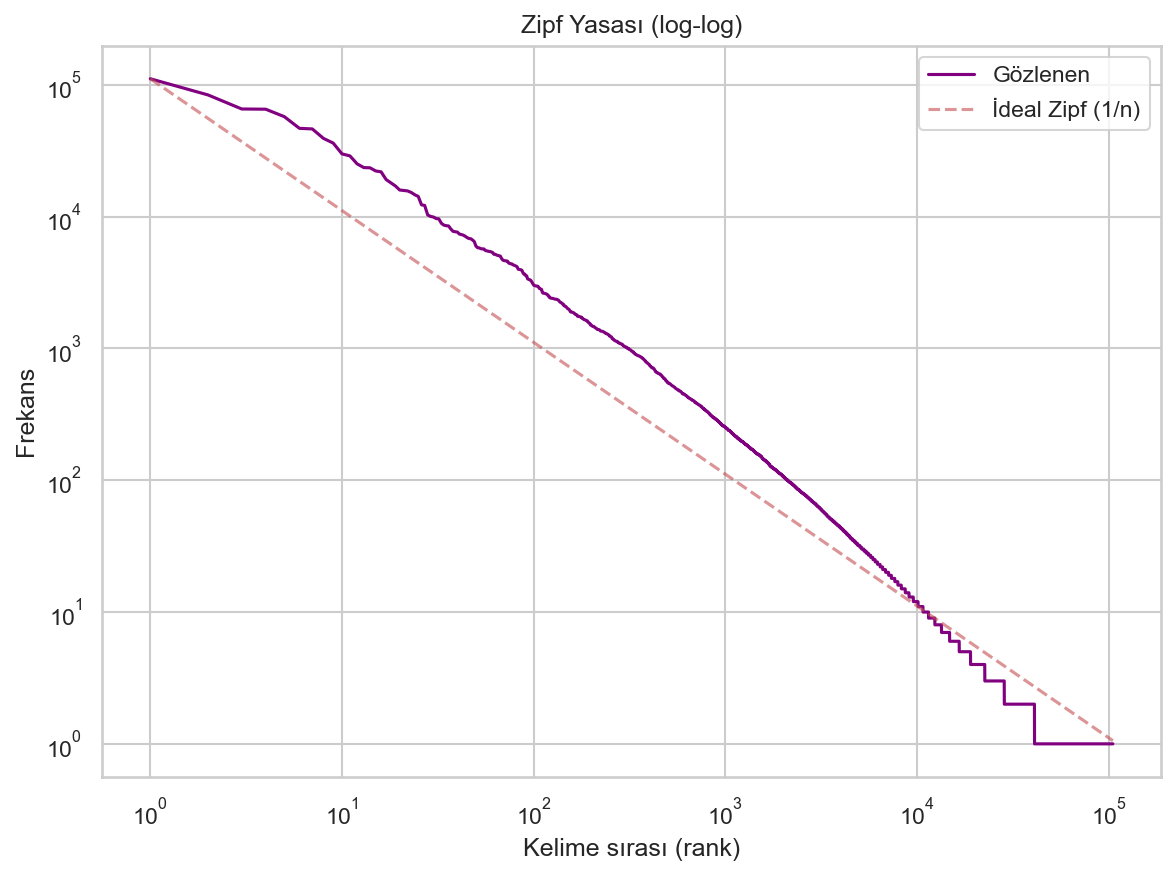

Negatif: 53,043 benzersiz kelime
Nötr : 54,828 benzersiz kelime


Pozitif: 48,198 benzersiz kelime
Toplam benzersiz kelime (örneklem): 105,147


In [18]:
# === EK ANALİZ: Zipf Yasası ve Kelime Çeşitliliği ===
from collections import Counter
samp = dfc.sample(min(30000, len(dfc)), random_state=42)
freq = Counter(' '.join(samp['text'].str.lower()).split())
ranks = np.arange(1, len(freq) + 1)
freqs = np.array(sorted(freq.values(), reverse=True))
plt.figure(figsize=(8, 6))
plt.loglog(ranks, freqs, color='purple', label='Gözlenen')
plt.loglog(ranks, freqs[0] / ranks, 'r--', alpha=0.6, label='İdeal Zipf (1/n)')
plt.title('Zipf Yasası (log-log)'); plt.xlabel('Kelime sırası (rank)')
plt.ylabel('Frekans'); plt.legend()
plt.tight_layout(); plt.savefig('results/eda_zipf.png'); plt.show()
for lbl, ad in [(0, 'Negatif'), (1, 'Nötr'), (2, 'Pozitif')]:
    w = set(' '.join(samp[samp['label'] == lbl]['text'].str.lower()).split())
    print(f'{ad:5s}: {len(w):,} benzersiz kelime')
print(f'Toplam benzersiz kelime (örneklem): {len(freq):,}')